In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Seaborn to make plot Prettier
import seaborn as sns

# Pokemon Data

In [8]:
# Import Data

df = pd.read_html("https://gist.github.com/armgilles/194bcff35001e7eb53a2a8b441e8b2c6#file-pokemon-csv")
df = df[0]
df = df[['Name', 'Type 1', 'Total', 'Legendary']]

df.head()

,Name,Type 1,Total,Legendary
0,Bulbasaur,Grass,318,False
1,Ivysaur,Grass,405,False
2,Venusaur,Grass,525,False
3,VenusaurMega Venusaur,Grass,625,False
4,Charmander,Fire,309,False


## Proportion Check

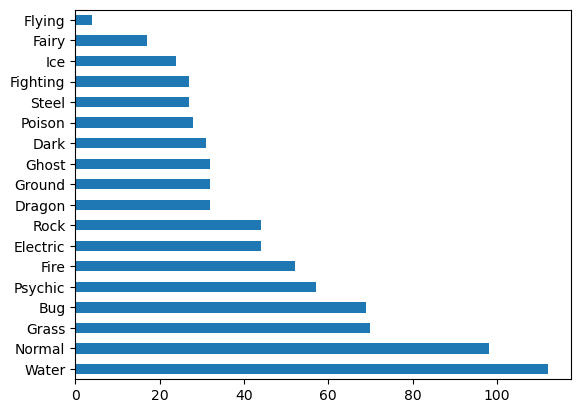

In [26]:
# Check For Pokemon Types
df['Type 1'].unique

# Check Propotion and Displaying
typeProportion = df['Type 1'].value_counts().plot.barh()

## Total Power Distribution

In [35]:
# Desctipbe Total Power Data
df.Total.describe()

count    800.00000
mean     435.10250
std      119.96304
min      180.00000
25%      330.00000
50%      450.00000
75%      515.00000
max      780.00000
Name: Total, dtype: float64

<AxesSubplot:ylabel='Frequency'>

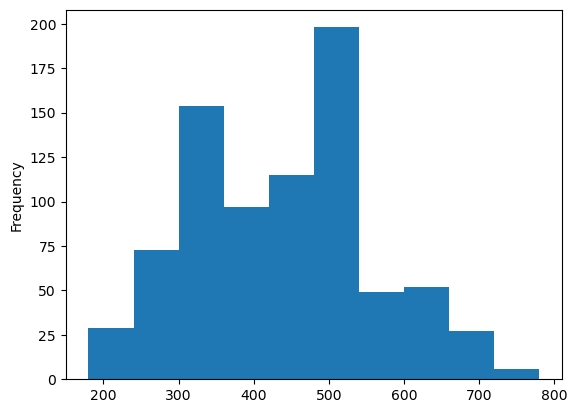

In [36]:
df.Total.plot.hist()

In [38]:
df.groupby(['Type 1']).mean()['Total']

Type 1
Bug         378.927536
Dark        445.741935
Dragon      550.531250
Electric    443.409091
Fairy       413.176471
Fighting    416.444444
Fire        458.076923
Flying      485.000000
Ghost       439.562500
Grass       421.142857
Ground      437.500000
Ice         433.458333
Normal      401.683673
Poison      399.142857
Psychic     475.947368
Rock        453.750000
Steel       487.703704
Water       430.455357
Name: Total, dtype: float64

In [53]:
df.groupby(['Type 1']).median()['Total'].sort_values().index

Index(['Bug', 'Poison', 'Fairy', 'Normal', 'Grass', 'Ground', 'Water',
       'Fighting', 'Ghost', 'Dark', 'Ice', 'Rock', 'Electric', 'Fire',
       'Psychic', 'Steel', 'Flying', 'Dragon'],
      dtype='object', name='Type 1')

Text(0.5, 1.0, 'Total Power Distribution by Type')

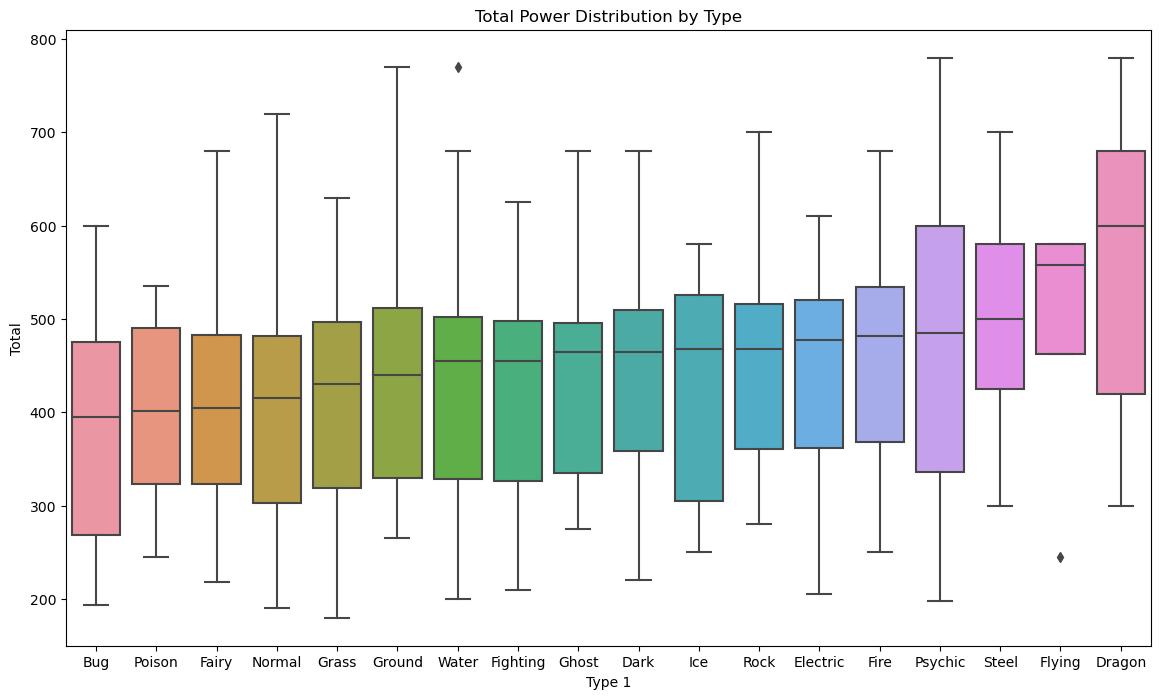

In [52]:
plt.figure(figsize=(14,8))
sns.boxplot(data=df,
            x='Type 1',
            y='Total',
            order=df.groupby(['Type 1']).median()['Total'].sort_values().index)
plt.title('Total Power Distribution by Type')

## Is Legendary Pokemon Stronger

Text(0.5, 1.0, 'Total Power Distribution by Legendary')

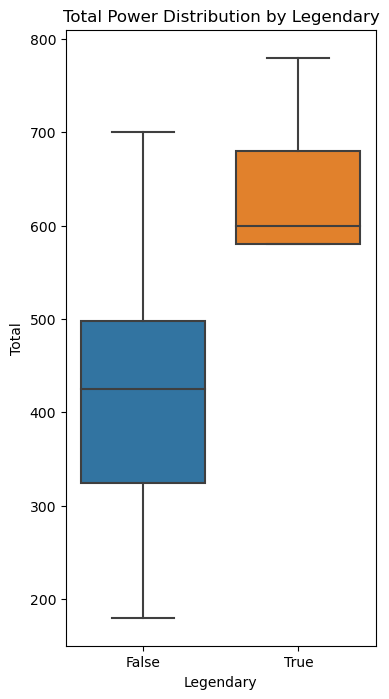

In [60]:
plt.figure(figsize=(4,8))
sns.boxplot(data=df,
            x='Legendary',
            y='Total',
            order=df.groupby(['Legendary']).median()['Total'].sort_values().index)
plt.title('Total Power Distribution by Legendary')

# Explore Data Car Performance

bit.do/binus_itrm

In [65]:
# Import Data

df_auto = pd.read_csv('./Dataset/autos.csv')

df_auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               193 non-null    object 
 1   fuel.type          193 non-null    object 
 2   aspiration         193 non-null    object 
 3   num.doors          193 non-null    int64  
 4   body.style         193 non-null    object 
 5   drive.wheels       193 non-null    object 
 6   engine.location    193 non-null    object 
 7   wheel.base         193 non-null    float64
 8   length             193 non-null    float64
 9   width              193 non-null    float64
 10  height             193 non-null    float64
 11  curb.weight        193 non-null    int64  
 12  engine.type        193 non-null    object 
 13  num.cylinders      193 non-null    int64  
 14  engine.size        193 non-null    int64  
 15  fuel.system        193 non-null    object 
 16  bore               193 non

<AxesSubplot:xlabel='make', ylabel='price'>

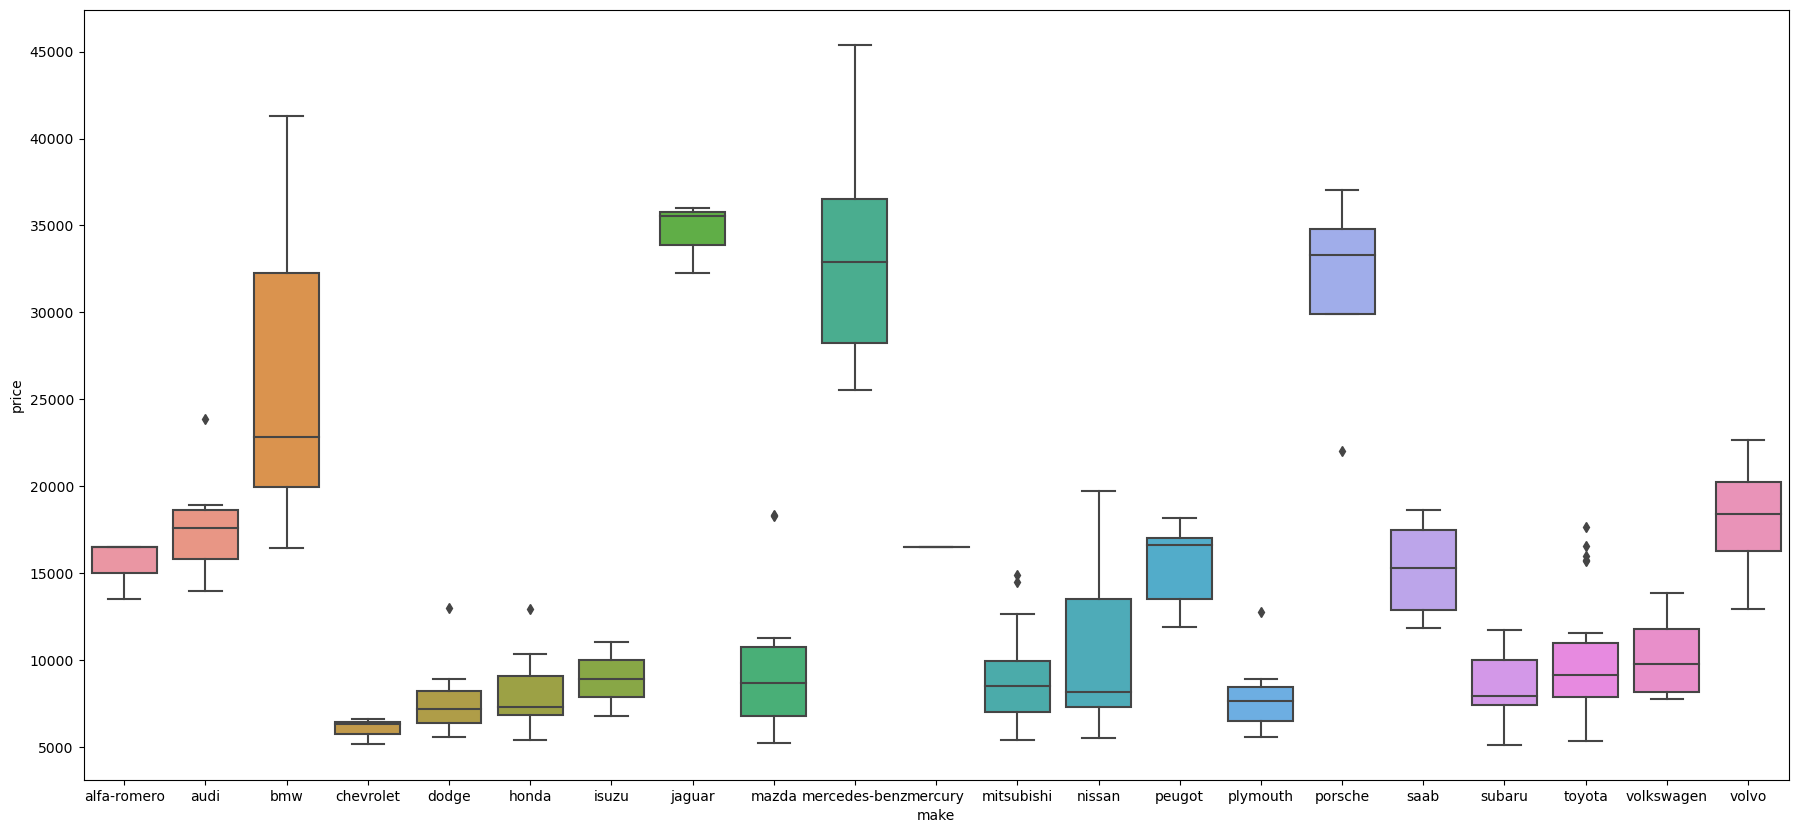

In [70]:
plt.figure(figsize=(22,10))
sns.boxplot(data=df_auto,
            x='make',
            y='price')

<AxesSubplot:xlabel='engine.location', ylabel='price'>

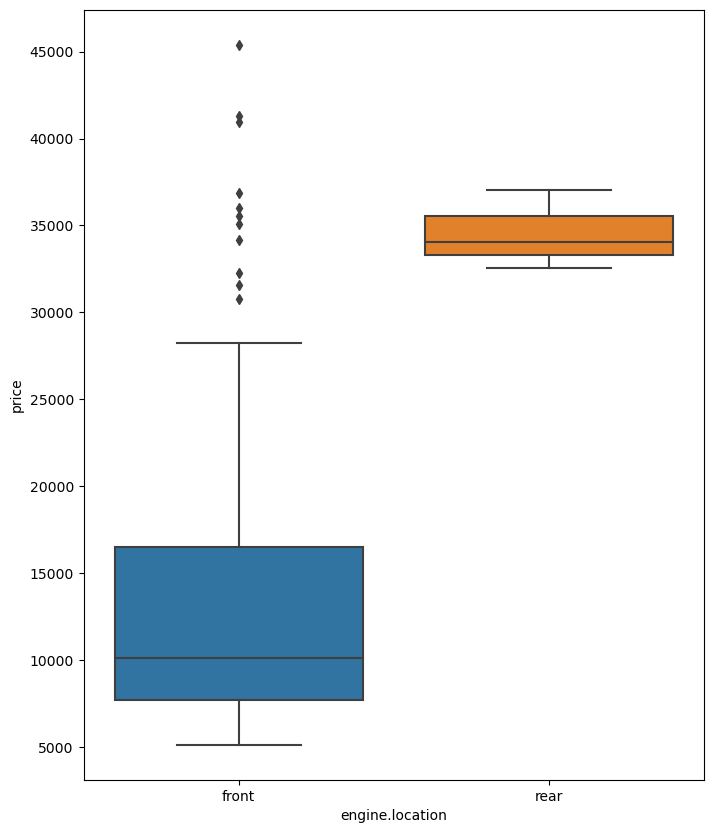

In [75]:
plt.figure(figsize=(8,10))
sns.boxplot(data=df_auto,
            x='engine.location',
            y='price')

<AxesSubplot:xlabel='body.style', ylabel='price'>

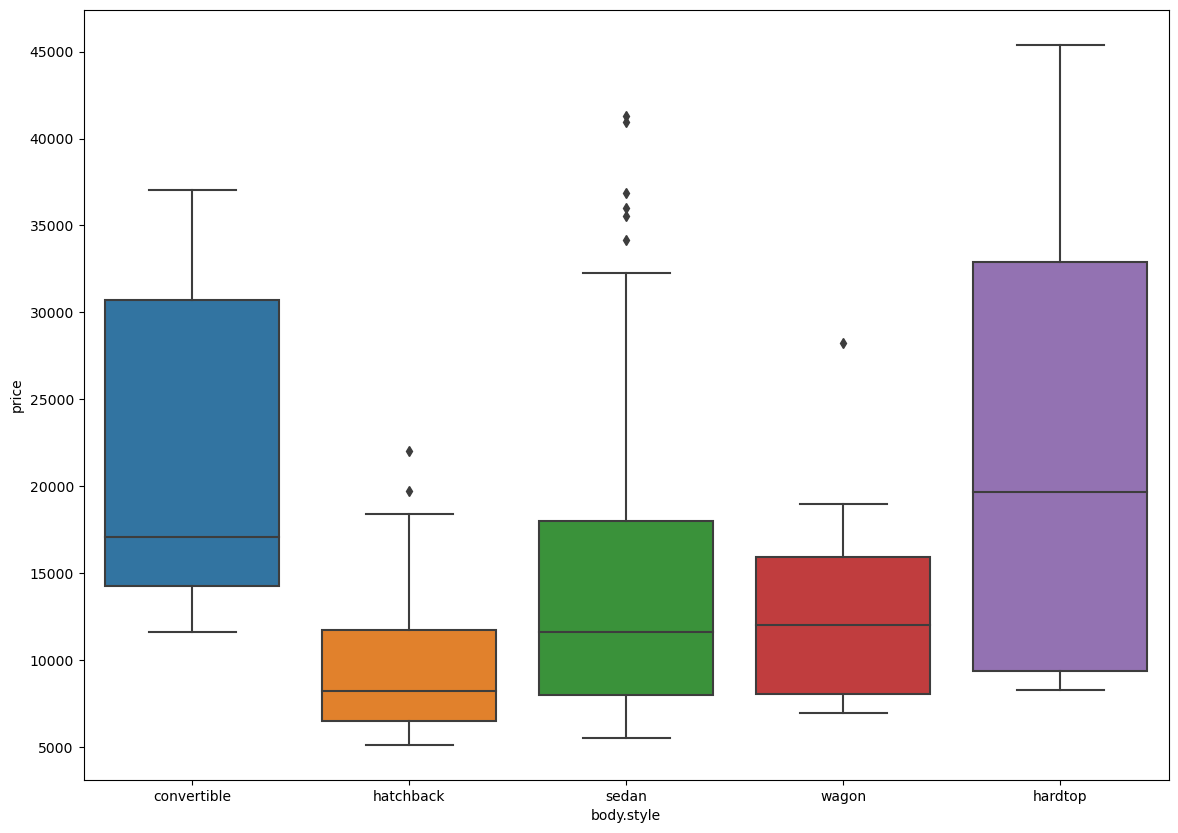

In [81]:
plt.figure(figsize=(14,10))
sns.boxplot(data=df_auto,
            x='body.style',
            y='price')

<AxesSubplot:xlabel='horsepower', ylabel='price'>

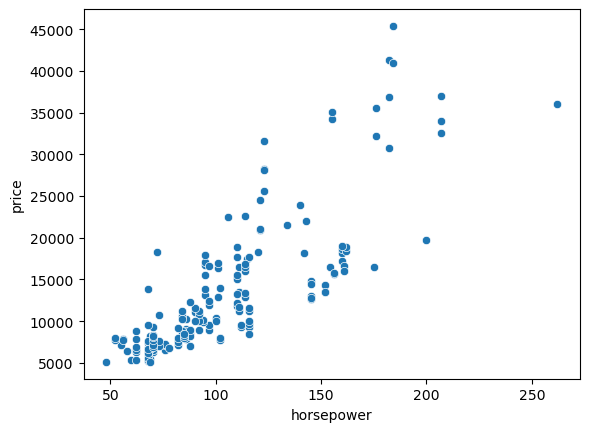

In [82]:
sns.scatterplot(data=df_auto,
            x='horsepower',
            y='price')

# Positif Corelation

<AxesSubplot:xlabel='city.mpg', ylabel='price'>

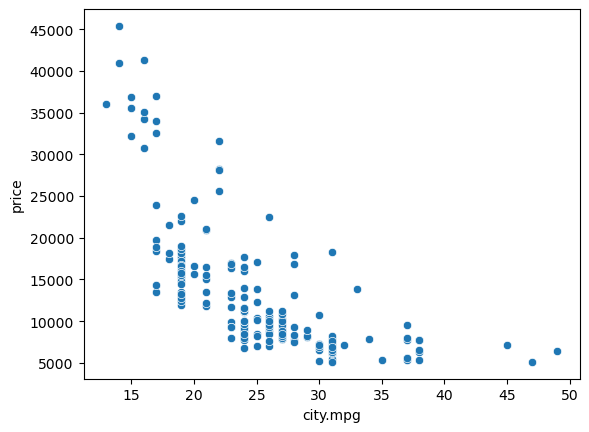

In [84]:
sns.scatterplot(data=df_auto,
            x='city.mpg',
            y='price')

# Negative Corelation

<AxesSubplot:xlabel='num.doors', ylabel='price'>

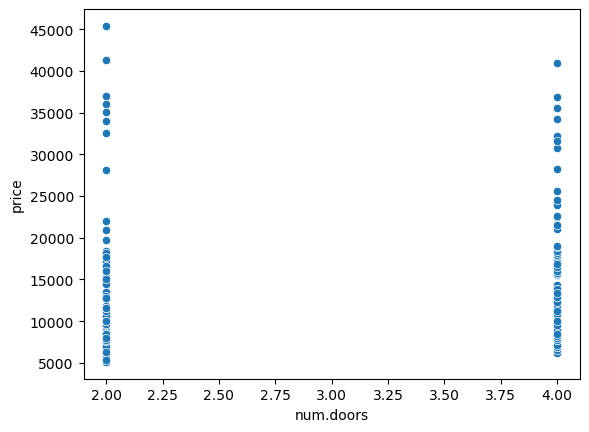

In [89]:
sns.scatterplot(data=df_auto,
            x='num.doors',
            y='price')

In [93]:
print(df_auto[['price', 'horsepower']].corr())
print(df_auto[['price', 'city.mpg']].corr())
print(df_auto[['price', 'num.doors']].corr())

               price  horsepower
price       1.000000    0.812453
horsepower  0.812453    1.000000
             price  city.mpg
price     1.000000 -0.706618
city.mpg -0.706618  1.000000
             price  num.doors
price      1.00000    0.04646
num.doors  0.04646    1.00000


In [106]:
# .corr to show corellation
df_auto.corr()[['price']].sort_values(by='price', ascending=False)

,price
price,1.000000
engine.size,0.888778
curb.weight,0.835368
horsepower,0.812453
width,0.754649
num.cylinders,0.746007
length,0.695928
wheel.base,0.584951
bore,0.546295
height,0.136234


<AxesSubplot:>

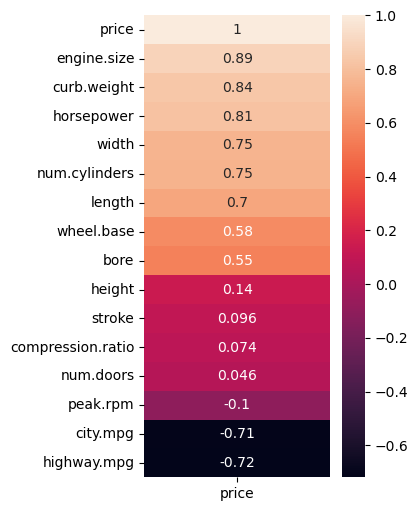

In [110]:
# heatmap to visualize corelation
plt.figure(figsize=(3,6))
sns.heatmap(df_auto.corr()[['price']].sort_values(by='price', ascending=False), annot=True)